# **TA Session 2. Universal Adversarial Perturbation (UAP)**


<font color="#EE0000">!! Before starting this TA session, make sure to use GPU (T4) runtime !!</font>

## **1. Preperation**

### **1-1. Mount Your Google drive**
For UAP generation dataset and evaluation dataset, you have to mount your Google drive.

In [18]:
# Mount your Google Drive!
# Do not change
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os

# Check if Google Drive is successfully mounted
print(os.path.isdir("/content/drive/MyDrive/UAP/train_sub"))
print(os.path.isdir("/content/drive/MyDrive/UAP/val_sub"))
print(os.path.isfile("/content/drive/MyDrive/UAP/imagenet_labels.txt"))

True
True
True


In [20]:
# Code Cell 2
# Do not Change

project_path = '/content/drive/MyDrive/UAP'
os.chdir(project_path)
print(f"working directory: {os.getcwd()}")

working directory: /content/drive/MyDrive/UAP


In [21]:
import torch
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import random

from basic_attack_core import apply_mi, apply_ti, apply_ni, apply_ni_decay, create_ti_conv, calculate_attack_ghat, update_mi_momentum
from evaluate import evaluate
import torch.nn.functional as F

random.seed=42

### **1-2. Dataset Load**

#### **Training Dataset**
In this practice section, we utilize subset of ImageNet training dataset, containing 1,000 images, one image per class.

#### **Validation Dataset**
We utilize subset of ImageNet validation dataset, containing 1,000 images, ones image per class.

In [22]:
# Define Transformations For Preprocessing
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# ImageNet Training Subset
dataset_train = ImageFolder(root='train_sub', transform=transform)
# ImageNet Validation Subset
dataset_val = ImageFolder(root='val_sub', transform=transform)

# Load datasets
train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)

### **1-3. Model Load**
In this TA session, we will use ResNet-50 as target model.

In [23]:
model = torchvision.models.resnet50(pretrained=True)
model = model.to('cuda')
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## **2. UAP Generation**

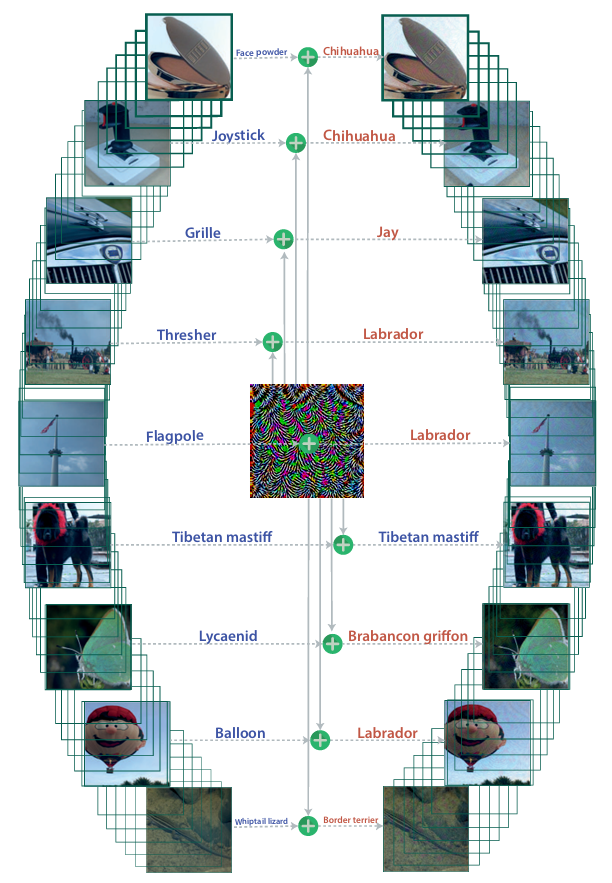

A single Universal Adversarial Perturbation (UAP) leads misinterpretation of model, when applied to any image.

In this TA session, you will generate a UAP using the **iterative Fast Gradient Sign Method (I-FGSM)** optimization on the ImageNet training dataset.


### **2-1. UAP Initialization**

In [24]:
# UAP initialization
uap = torch.zeros((3, 224, 224)).to('cuda')
# For UAP update, set requires_grad True
uap.requires_grad = True

### **2-2. Hyperparameter initialization**

If you want to other UAP optimization techniques, feel free to add other hyperparameters you need.

In [25]:
# hyperparameters for UAP generation (FGSM)
max_epsilon=12
step_size=0.7


### **2-3. SGD-UAP optimization**

In this practice section, **SGD-UAP** is utilized for UAP optimization.
For fast convergence, we will adopt I-FGSM-based optimization.

SGD-UAP with I-FGSM:

$\delta^{t+1} = \delta^{t} + \alpha\cdot\mathrm{Sign}\{∇_{\delta^t}(\frac{1}{|X_t|}\sum_{x \in X_t}J(x+\delta^t, y))\},$

$\delta^t = \mathrm{Clamp}_{\epsilon}(\delta^t),$

where $X_t$ is the image batch at $t$-th iteration, $J(x,y)$ is the loss functions with input image $x$ and label $y$. $\delta^t$ is the adversarial perturbation at $t$-th iteration. $\mathrm{Clamp}$ restricts the pixel value of the perturbation within the range of $[-\epsilon, \epsilon]$. $\alpha$ is the step size, which is a hyperparameter.

We will utilize cross entropy loss as the loss function.

In [26]:
for epoch in range(5):  # number of epochs
    for i, data in tqdm(enumerate(train_loader), total=len(train_loader)):
        inputs, labels = data
        inputs = inputs.to('cuda')
        labels = labels.to('cuda')

        eps = max_epsilon / 255.0
        alpha = step_size / 255.0

        # =================== TODO 1 ======================
        # Prepare adversarial inputs
        # Add UAP to clean inputs
        adv_inputs = inputs + uap.unsqueeze(0)
        # clamp adversarial input with [0,1] range
        adv_inputs = adv_inputs.clamp(0, 1)
        # normalize input
        adv_inputs = normalize(adv_inputs)
        # ================================================


        # =================== TODO 1 ======================
        # Get adversarial model output
        outputs = model(adv_inputs)
        # Calculate loss
        loss = F.cross_entropy(outputs, labels)
        # ================================================


        loss.backward()
        grad = uap.grad.data

        # =================== TODO 1 ======================
        # Update UAP with FGSM
        uap.data = uap.data + alpha * torch.sign(grad)
        # clamp UAP with epsilon value
        uap.data = uap.data.clamp(-eps, eps)
        # ================================================

        uap.grad.data.zero_()

100%|██████████| 125/125 [00:12<00:00,  9.94it/s]


### 2-4. Transferable UAP Generation

You can implement fature-level universal adversarial attack (**PG-UAP**) for transferability.

You can also apply MNI-DTS methods for transferability.

Please modify **basic_attack_core.py** file.

In [27]:
# UAP initialization
uap_transfer = torch.zeros((3, 224, 224)).to('cuda')
# uap_transfer = uap.clone().detach().to('cuda')

# For UAP update, set requires_grad True
uap_transfer.requires_grad = True

In [28]:
# hyperparameters for UAP generation (FGSM)
max_epsilon=12
step_size=0.7

# Hyperparameter tuning
# ======================= TODO 8 =======================
attack_type = "MNDTS"
mu = 1.0
number_of_si_scales = 1
di_prob = 0.4
di_pad_amount = 31
di_pad_value = 0
ti_kernel_size = 1
feature_attack = True
depth = 'layer4'
# ======================================================

target_label = -1



In [29]:
for epoch in range(5):  # number of epochs
    g = 0
    for i, data in tqdm(enumerate(train_loader), total=len(train_loader)):
        inputs, labels = data
        inputs = inputs.to('cuda')
        labels = labels.to('cuda')

        mu = max(apply_mi(attack_type, mu), apply_ni_decay(attack_type, mu))

        ti_conv = None
        if 'T' in attack_type:  # Create smoothing kernel for translation-invariance.
            ti_conv = create_ti_conv(inputs.device, ti_kernel_size)

        model.eval()

        eps = max_epsilon / 255.0  # epsilon in scale [0, 1]
        alpha = step_size / 255.0   # alpha in scale [0, 1]

        x_adv = inputs + uap_transfer.unsqueeze(0)
        x_adv = normalize(x_adv.clamp(0, 1))
        x_clean = normalize(inputs)

        # Calculate ghat from the current adversarial point.
        x_adv_or_nes = apply_ni(attack_type, x_adv, alpha, mu, g)

        ghat = calculate_attack_ghat(model, x_adv_or_nes, labels, number_of_si_scales, target_label, attack_type,
                                    di_prob, di_pad_amount, di_pad_value, feature_attack, x_clean, depth)

        # Update g (momentum accumulator)
        ghat = apply_ti(ghat, attack_type, ti_conv)
        g = update_mi_momentum(g, ghat, mu)

        # Batch mean of gradient
        g = torch.mean(g, dim=0)

        # Update uap
        pert = alpha * g.sign()
        uap_transfer = uap_transfer + pert

        uap_transfer.data = uap_transfer.data.clamp(-eps, eps)

100%|██████████| 125/125 [00:15<00:00,  7.97it/s]


## **3. White-box Evaluation**

### **3-1. Evaluation for Clean Data**

In [30]:
correct = 0
total = 0

for i, data in tqdm(enumerate(val_loader), total=len(val_loader)):
    inputs, labels = data
    inputs = inputs.to('cuda')
    labels = labels.to('cuda')

    inputs = normalize(inputs)

    outputs = model(inputs)
    predicted = torch.argmax(outputs.data, dim=1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the model on clean validation images: {} %'.format(100 * correct / total))

100%|██████████| 32/32 [04:40<00:00,  8.76s/it]

Accuracy of the model on clean validation images: 76.1 %


### **3-2. Evaluation for Random Noise**

For a fair comparison, we define a random noise with pixel value within the range $[-\epsilon, \epsilon]$.

In [31]:
correct = 0
total = 0

# Define Random noise with pixel value [-eps, eps]
random_noise = (torch.rand_like(uap) * 2 - 1) * eps


for i, data in tqdm(enumerate(val_loader), total=len(val_loader)):
    inputs, labels = data
    inputs = inputs.to('cuda')
    labels = labels.to('cuda')


    # Prepare adversarial inputs
    # Add UAP to clean inputs
    adv_inputs_random = inputs + random_noise.unsqueeze(0)
    # clamp adversarial inputs within [0,1] range
    adv_inputs_random = adv_inputs_random.clamp(0, 1)
    # normalize adversarial input
    adv_inputs_random = normalize(adv_inputs_random)

    outputs = model(adv_inputs_random)
    predicted = torch.argmax(outputs.data, dim=1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

asr = 100*(1-(correct/total))
print(f'Attack Success Rate: {asr}%')

100%|██████████| 32/32 [00:12<00:00,  2.47it/s]

Attack Success Rate: 27.800000000000004%


### **3-3. Evaluation for SGD-UAP**

In [32]:
correct=0
total=0

for i, data in tqdm(enumerate(val_loader), total=len(val_loader)):

    inputs, labels = data
    inputs = inputs.to('cuda')
    labels = labels.to('cuda')


    # Prepare adversarial inputs
    # Add UAP to clean inputs
    adv_inputs = inputs + uap.unsqueeze(0)
    # clamp adversarial inputs within [0,1] range
    adv_inputs = adv_inputs.clamp(0, 1)
    # normalize adversarial input
    adv_inputs = normalize(adv_inputs)


    outputs = model(adv_inputs)
    predicted = F.softmax(outputs.data, dim=1).max(dim=1)
    # print(predicted)

    total += labels.size(0)
    correct += torch.sum((predicted[1] == labels).float()).item()

asr = 100*(1-(correct/total))
print(f'Attack Success Rate: {asr}%')

100%|██████████| 32/32 [00:12<00:00,  2.47it/s]

Attack Success Rate: 94.6%


### **3-4. Evaluation for transferable UAP (whitebox)**

In [33]:
correct=0
total=0

for i, data in tqdm(enumerate(val_loader), total=len(val_loader)):

    inputs, labels = data
    inputs = inputs.to('cuda')
    labels = labels.to('cuda')


    # Prepare adversarial inputs
    # Add UAP to clean inputs
    adv_inputs = inputs + uap_transfer.unsqueeze(0)
    # clamp adversarial inputs within [0,1] range
    adv_inputs = adv_inputs.clamp(0, 1)
    # normalize adversarial input
    adv_inputs = normalize(adv_inputs)


    outputs = model(adv_inputs)
    predicted = F.softmax(outputs.data, dim=1).max(dim=1)
    # print(predicted)

    total += labels.size(0)
    correct += torch.sum((predicted[1] == labels).float()).item()

asr = 100*(1-(correct/total))
print(f'Attack Success Rate: {asr}%')

100%|██████████| 32/32 [00:13<00:00,  2.42it/s]

Attack Success Rate: 94.3%


## **4. Visualization**

### 4-1. UAP Visualization

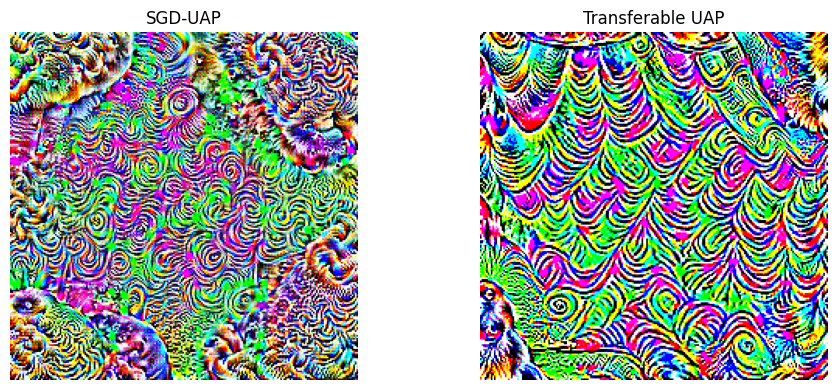

In [34]:
import matplotlib.pyplot as plt

# Rescale uap [-eps, eps] to [0,1]
uap_vis = (uap + eps) / (eps * 2)
uap_vis = uap_vis.detach().cpu().permute(1, 2, 0).numpy()

uap_transfer_vis = (uap_transfer + eps) / (eps * 2)
uap_transfer_vis = uap_transfer_vis.detach().cpu().permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(uap_vis)
axes[0].set_title('SGD-UAP')
axes[0].axis('off')

axes[1].imshow(uap_transfer_vis)
axes[1].set_title('Transferable UAP')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 4-2. Model Prediction Visualization

In [35]:
# Numerical label to text label for visualization
def read_txt_to_dict(file_path):
    my_dict = {}
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            line = line.strip('{')
            line = line.strip('}')
            if line:
                key_value = line.split(': ', 1)
                key = int(key_value[0])
                value = key_value[1].strip().rstrip(",").strip("'")
                my_dict[key] = value
    return my_dict

# imagenet_labels_dict = read_txt_to_dict('/content/drive/MyDrive/UAP_dataset/imagenet_labels.txt')
imagenet_labels_dict = read_txt_to_dict('imagenet_labels.txt')

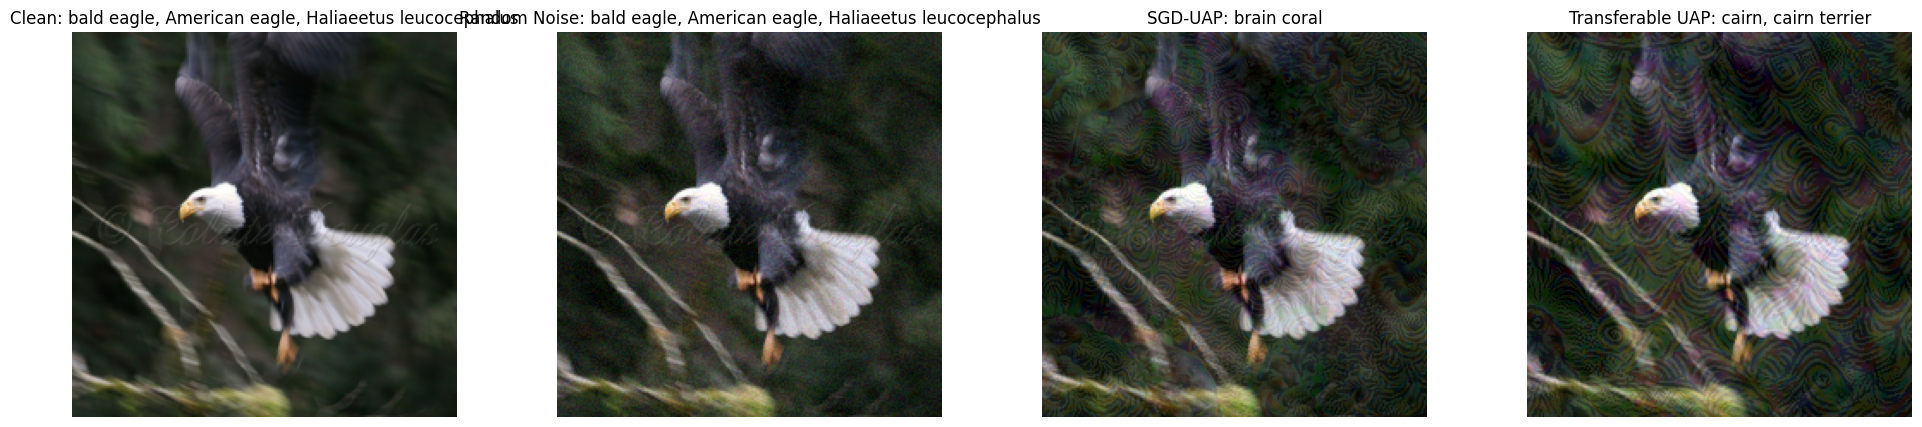

In [36]:
import matplotlib.pyplot as plt

random_index = random.randint(0, len(val_loader))
data = val_loader.dataset[random_index]

inputs, labels = data
inputs = inputs.to('cuda')
inputs = inputs.unsqueeze(0)

input_norm = normalize(inputs)
clean_output = model(input_norm)
clean_predicted = torch.argmax(clean_output.data, dim=1)

adv_input_random = inputs + random_noise.unsqueeze(0)
adv_input_random = adv_input_random.clamp(0, 1)
adv_input_random_norm = normalize(adv_input_random)

adv_input = inputs + uap.unsqueeze(0)
adv_input = adv_input.clamp(0, 1)
adv_input_norm = normalize(adv_input)

# uap_transfer
adv_input_transfer = inputs + uap_transfer.unsqueeze(0)
adv_input_transfer = adv_input_transfer.clamp(0, 1)
adv_input_transfer_norm = normalize(adv_input_transfer)

adv_random_output = model(adv_input_random_norm)
adv_random_predicted = torch.argmax(adv_random_output.data, dim=1)

adv_output = model(adv_input_norm)
adv_predicted = torch.argmax(adv_output.data, dim=1)

adv_transfer_output = model(adv_input_transfer_norm)
adv_transfer_predicted = torch.argmax(adv_transfer_output.data, dim=1)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].imshow(inputs[0].detach().cpu().permute(1, 2, 0).numpy())
axes[0].set_title(f"Clean: {imagenet_labels_dict[clean_predicted[0].item()]}", wrap=True)
axes[0].axis("off")

axes[1].imshow(adv_input_random[0].detach().cpu().permute(1, 2, 0).numpy())
axes[1].set_title(f"Random Noise: {imagenet_labels_dict[adv_random_predicted[0].item()]}", wrap=True)
axes[1].axis("off")

axes[2].imshow(adv_input[0].detach().cpu().permute(1, 2, 0).numpy())
axes[2].set_title(f"SGD-UAP: {imagenet_labels_dict[adv_predicted[0].item()]}", wrap=True)
axes[2].axis("off")

axes[3].imshow(adv_input_transfer[0].detach().cpu().permute(1, 2, 0).numpy())
axes[3].set_title(f"Transferable UAP: {imagenet_labels_dict[adv_transfer_predicted[0].item()]}", wrap=True)
axes[3].axis("off")

plt.show()




## **5. Black-box Evalution**

### **5-1. SGD-UAP black-box evaluation**

In [37]:
evaluate(dataset_val, val_loader, uap)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 133MB/s]
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name adv_inception_v3 to current inception_v3.tf_adv_in1k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

ResNet50
[1/32] SR (%) on ResNet18 with MNI-DTS : 78.12
[1/32] SR (%) on ResNet50 with MNI-DTS : 93.75
[1/32] SR (%) on inception_v3_timm with MNI-DTS : 40.62
[1/32] SR (%) on inception_v4_timm with MNI-DTS : 59.38
[1/32] SR (%) on DenseNet121 with MNI-DTS : 65.62
[1/32] SR (%) on adv_inception_v3 with MNI-DTS : 31.25
[2/32] SR (%) on ResNet18 with MNI-DTS : 68.75
[2/32] SR (%) on ResNet50 with MNI-DTS : 93.75
[2/32] SR (%) on inception_v3_timm with MNI-DTS : 43.75
[2/32] SR (%) on inception_v4_timm with MNI-DTS : 56.25
[2/32] SR (%) on DenseNet121 with MNI-DTS : 62.50
[2/32] SR (%) on adv_inception_v3 with MNI-DTS : 40.62
[3/32] SR (%) on ResNet18 with MNI-DTS : 64.58
[3/32] SR (%) on ResNet50 with MNI-DTS : 94.79
[3/32] SR (%) on inception_v3_timm with MNI-DTS : 38.54
[3/32] SR (%) on inception_v4_timm with MNI-DTS : 48.96
[3/32] SR (%) on DenseNet121 with MNI-DTS : 60.42
[3/32] SR (%) on adv_inception_v3 with MNI-DTS : 34.38
[4/32] SR (%) on ResNet18 with MNI-DTS : 62.50
[4/32] SR (

### **5-2. Transferable UAP black-box evaluation**

In [38]:
evaluate(dataset_val, val_loader, uap_transfer)

ResNet50
[1/32] SR (%) on ResNet18 with MNI-DTS : 90.62
[1/32] SR (%) on ResNet50 with MNI-DTS : 93.75
[1/32] SR (%) on inception_v3_timm with MNI-DTS : 78.12
[1/32] SR (%) on inception_v4_timm with MNI-DTS : 87.50
[1/32] SR (%) on DenseNet121 with MNI-DTS : 84.38
[1/32] SR (%) on adv_inception_v3 with MNI-DTS : 46.88
[2/32] SR (%) on ResNet18 with MNI-DTS : 90.62
[2/32] SR (%) on ResNet50 with MNI-DTS : 93.75
[2/32] SR (%) on inception_v3_timm with MNI-DTS : 76.56
[2/32] SR (%) on inception_v4_timm with MNI-DTS : 85.94
[2/32] SR (%) on DenseNet121 with MNI-DTS : 82.81
[2/32] SR (%) on adv_inception_v3 with MNI-DTS : 48.44
[3/32] SR (%) on ResNet18 with MNI-DTS : 89.58
[3/32] SR (%) on ResNet50 with MNI-DTS : 93.75
[3/32] SR (%) on inception_v3_timm with MNI-DTS : 76.04
[3/32] SR (%) on inception_v4_timm with MNI-DTS : 83.33
[3/32] SR (%) on DenseNet121 with MNI-DTS : 84.38
[3/32] SR (%) on adv_inception_v3 with MNI-DTS : 43.75
[4/32] SR (%) on ResNet18 with MNI-DTS : 89.06
[4/32] SR (